## Revising supervised ml : 23/4/26

In [1]:
### importing the important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stat
import pylab

In [2]:
### loading the data frame
df = pd.read_csv('../v2/supervised_ml/data/raw/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
### checking the null values
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
### checking the duplicate values and the shape of the data
print(f"{df.duplicated().sum()} :: {df.shape}")

0 :: (20640, 10)


In [5]:
### randomizing the df
df = df.sample(frac = 1).reset_index(drop = True)

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-117.39,33.96,49.0,2527.0,461.0,1344.0,451.0,4.0833,114400.0,INLAND
1,-118.46,34.22,31.0,2057.0,601.0,2397.0,579.0,2.8710,184400.0,<1H OCEAN
2,-117.09,34.01,37.0,106.0,18.0,27.0,12.0,4.0556,131300.0,INLAND
3,-122.48,38.50,37.0,3049.0,NaN,1287.0,439.0,4.3125,276500.0,INLAND
4,-117.97,34.01,33.0,3530.0,700.0,2959.0,679.0,3.7459,152900.0,<1H OCEAN


In [27]:
### making the earliest possible split
from sklearn.model_selection import train_test_split
df_train, df_valid = train_test_split(df, random_state = 42, test_size = 0.25)
print(f"{df_train.shape} :: {df_valid.shape}")

(15480, 10) :: (5160, 10)


In [28]:
### df_train.head()
df_train.reset_index(drop = True, inplace = True)
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-121.32,38.01,20.0,1903.0,395.0,919.0,359.0,2.6765,96400.0,INLAND
1,-118.12,34.14,25.0,3420.0,977.0,1718.0,947.0,3.1033,217900.0,<1H OCEAN
2,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,187500.0,NEAR BAY
3,-117.07,32.68,18.0,1475.0,267.0,1149.0,268.0,5.0827,142200.0,NEAR OCEAN
4,-117.94,34.08,32.0,2704.0,514.0,1669.0,497.0,4.4653,195400.0,<1H OCEAN


In [29]:
### nan in df_train
df_train.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        162
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [30]:
### df_valid.head()
df_valid.reset_index(drop = True, inplace = True)
df_valid.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.72,40.17,16.0,396.0,78.0,188.0,72.0,1.3889,87500.0,INLAND
1,-118.04,33.99,47.0,2530.0,565.0,1262.0,509.0,3.6475,197100.0,<1H OCEAN
2,-121.19,38.67,16.0,1754.0,284.0,773.0,277.0,4.8170,147000.0,INLAND
3,-121.96,37.96,28.0,1838.0,273.0,899.0,270.0,5.2145,229200.0,INLAND
4,-118.48,33.96,16.0,895.0,181.0,237.0,149.0,12.0088,500001.0,<1H OCEAN


In [31]:
### nan in df_valid
df_valid.isna().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        45
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
dtype: int64

In [32]:
### dropping the target feature and storing it as a different variable to check later out
y_true_valid = df_valid['median_house_value']
y_true_valid

0        87500.0
1       197100.0
2       147000.0
3       229200.0
4       500001.0
          ...   
5155     82600.0
5156     59900.0
5157    359600.0
5158    111300.0
5159    364000.0
Name: median_house_value, Length: 5160, dtype: float64

In [33]:
### dropping it from the df_valid
df_valid.drop('median_house_value', axis = 1, inplace = True)
df_valid.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.72,40.17,16.0,396.0,78.0,188.0,72.0,1.3889,INLAND
1,-118.04,33.99,47.0,2530.0,565.0,1262.0,509.0,3.6475,<1H OCEAN
2,-121.19,38.67,16.0,1754.0,284.0,773.0,277.0,4.8170,INLAND
3,-121.96,37.96,28.0,1838.0,273.0,899.0,270.0,5.2145,INLAND
4,-118.48,33.96,16.0,895.0,181.0,237.0,149.0,12.0088,<1H OCEAN


In [34]:
### fixing the nan in the df_train now
df_train['total_bedrooms'] = df_train['total_bedrooms'].fillna(df_train['total_bedrooms'].median())
df_train.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [35]:
### fixing the nan in the df_valid now
df_valid['total_bedrooms'] = df_valid['total_bedrooms'].fillna(df_valid['total_bedrooms'].median())
df_valid.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [36]:
### df_train.head() to plan ahead
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-121.32,38.01,20.0,1903.0,395.0,919.0,359.0,2.6765,96400.0,INLAND
1,-118.12,34.14,25.0,3420.0,977.0,1718.0,947.0,3.1033,217900.0,<1H OCEAN
2,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,187500.0,NEAR BAY
3,-117.07,32.68,18.0,1475.0,267.0,1149.0,268.0,5.0827,142200.0,NEAR OCEAN
4,-117.94,34.08,32.0,2704.0,514.0,1669.0,497.0,4.4653,195400.0,<1H OCEAN


In [37]:
#### targeting the ocean proximity column first
df_train['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     6889
INLAND        4914
NEAR OCEAN    1990
NEAR BAY      1682
ISLAND           5
Name: count, dtype: int64

In [38]:
### label encoding the values for df_train
df_train['ocean_proximity'] = df_train['ocean_proximity'].map({
'<1H OCEAN' : 1, 
'INLAND' : 0,       
'NEAR OCEAN' : 3, 
'NEAR BAY' : 2,
'ISLAND' : 4     
})
df_train['ocean_proximity'].value_counts()

ocean_proximity
1    6889
0    4914
3    1990
2    1682
4       5
Name: count, dtype: int64

In [39]:
### checking the value counts
df_valid['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     2247
INLAND        1637
NEAR OCEAN     668
NEAR BAY       608
Name: count, dtype: int64

In [40]:
### label encoding the values for df_valid
df_valid['ocean_proximity'] = df_valid['ocean_proximity'].map({
'<1H OCEAN' : 1, 
'INLAND' : 0,       
'NEAR OCEAN' : 3, 
'NEAR BAY' : 2,
'ISLAND' : 4     
})
df_valid['ocean_proximity'].value_counts()

ocean_proximity
1    2247
0    1637
3     668
2     608
Name: count, dtype: int64

In [41]:
### df_train.head()
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-121.32,38.01,20.0,1903.0,395.0,919.0,359.0,2.6765,96400.0,0
1,-118.12,34.14,25.0,3420.0,977.0,1718.0,947.0,3.1033,217900.0,1
2,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,187500.0,2
3,-117.07,32.68,18.0,1475.0,267.0,1149.0,268.0,5.0827,142200.0,3
4,-117.94,34.08,32.0,2704.0,514.0,1669.0,497.0,4.4653,195400.0,1


In [22]:
### writing off a function to plot the followings : QQ, line graph and box plot
def plot_graphs(df) : 

    cols = df.select_dtypes(include = ['float64'])

    for col in cols : 

        print(f"column : {col}")
        plt.figure(figsize = (12, 4))

        #---------first plot, which is a hist plot        
        plt.subplot(1, 3, 1)
        plt.title('Hist plot')
        df[col].hist()

        #----------second one, which is a qq plot
        plt.subplot(1, 3, 2)
        plt.title('QQ plot')
        stat.probplot(df[col], dist = 'norm', plot = pylab)
        
        #----------third plot, box plot
        plt.subplot(1, 3, 3)
        plt.title('Boxplot')
        sns.boxplot(df[col])

        plt.show()

column : longitude


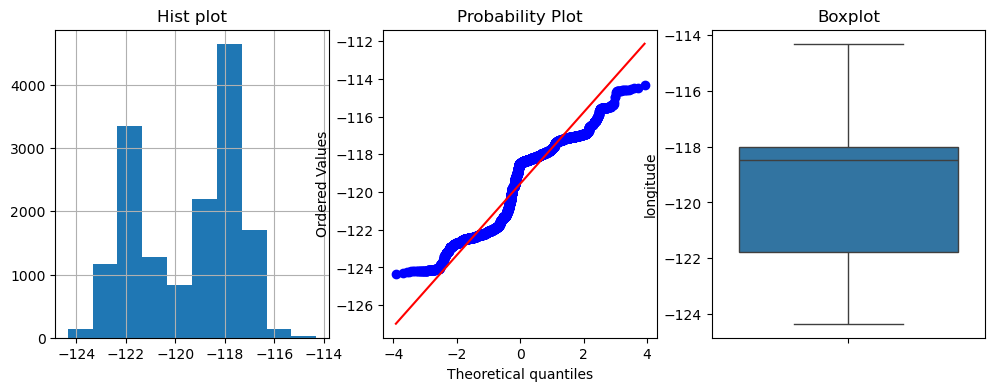

column : latitude


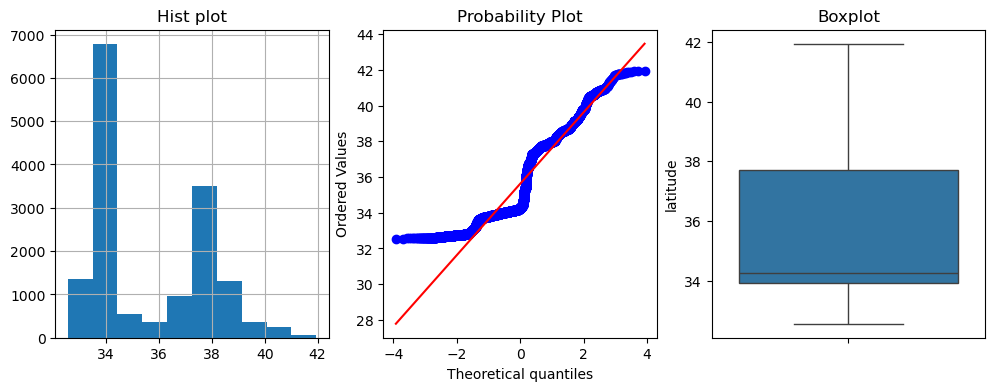

column : housing_median_age


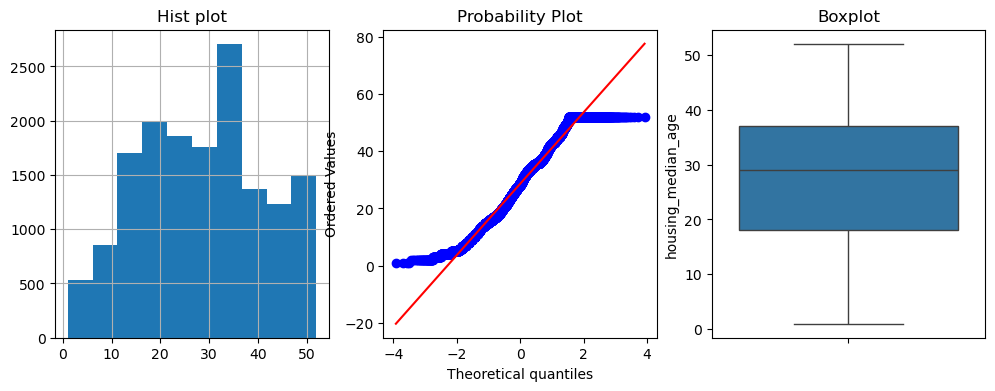

column : total_rooms


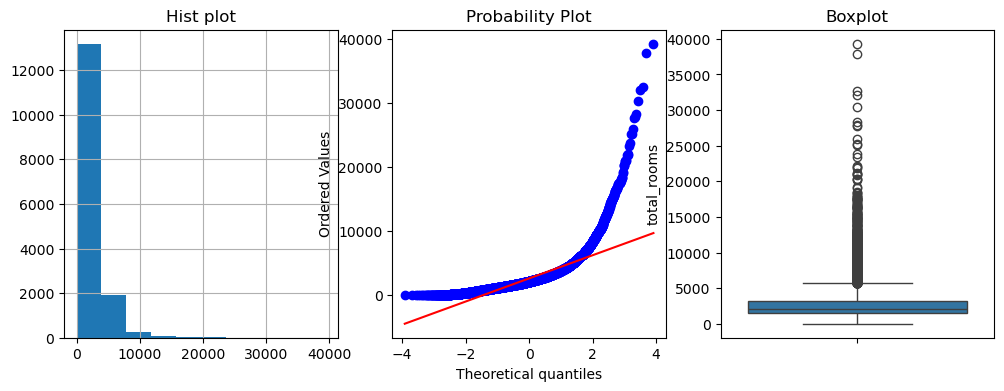

column : total_bedrooms


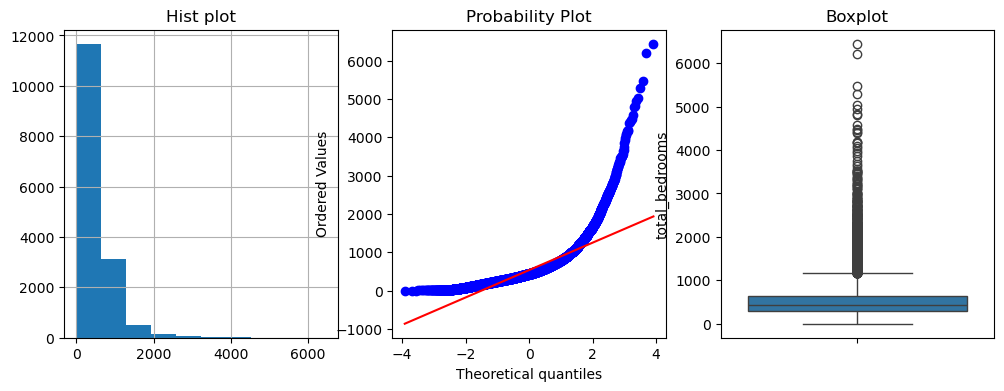

column : population


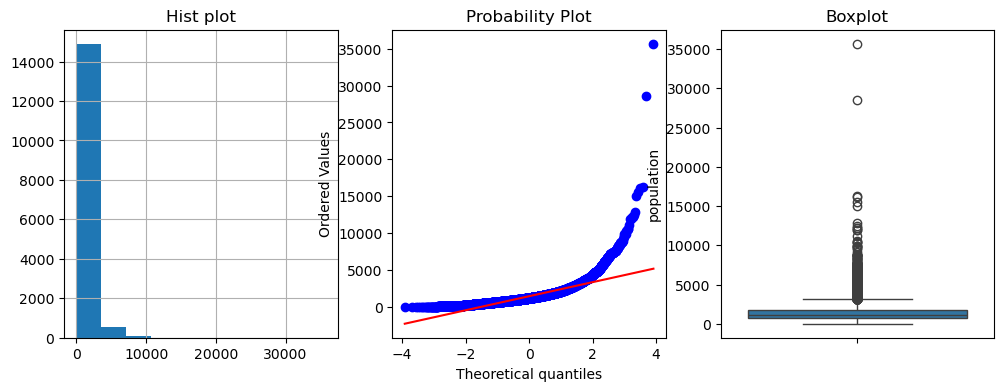

column : households


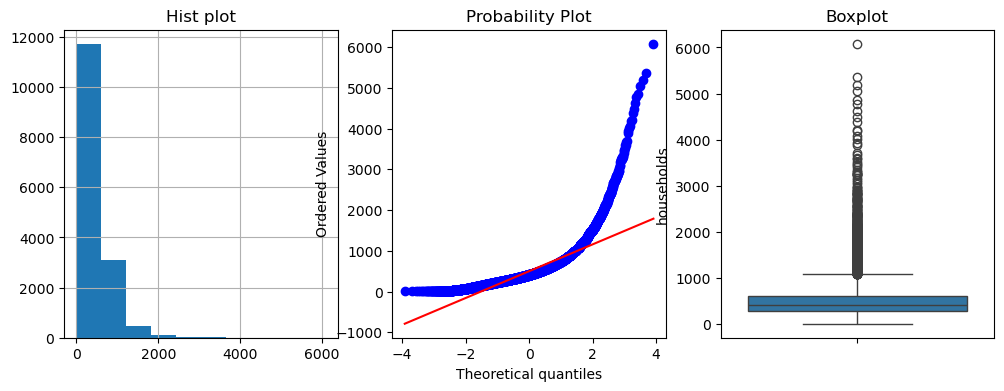

column : median_income


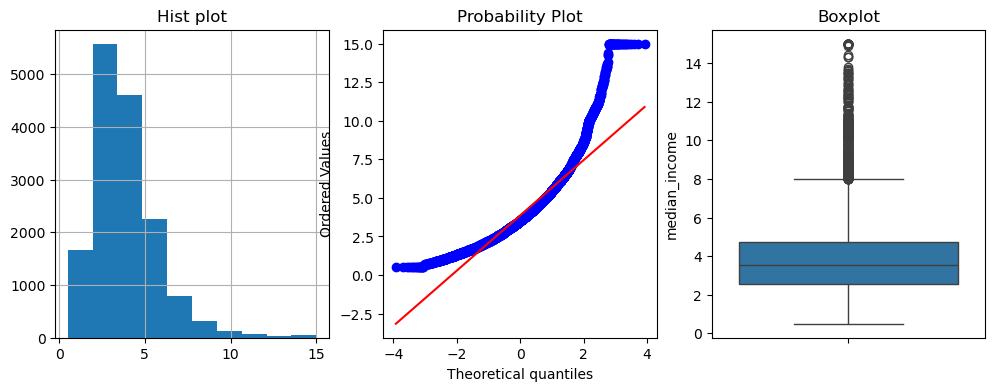

column : median_house_value


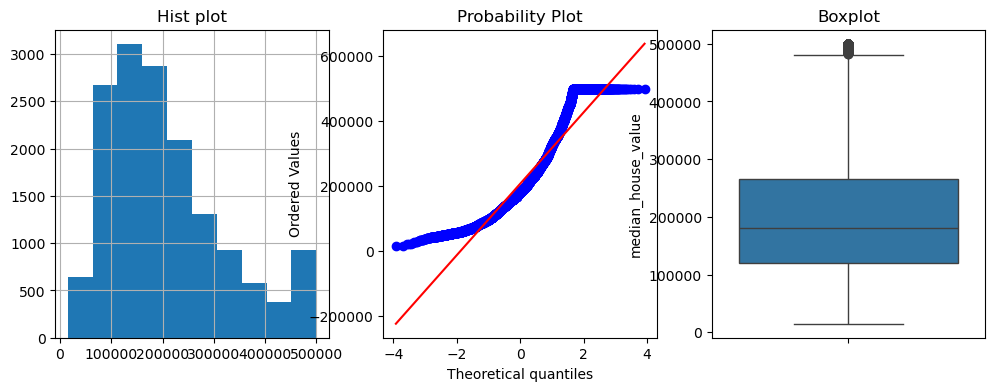

In [23]:
### plotting for the df_train
plot_graphs(df_train)

column : longitude


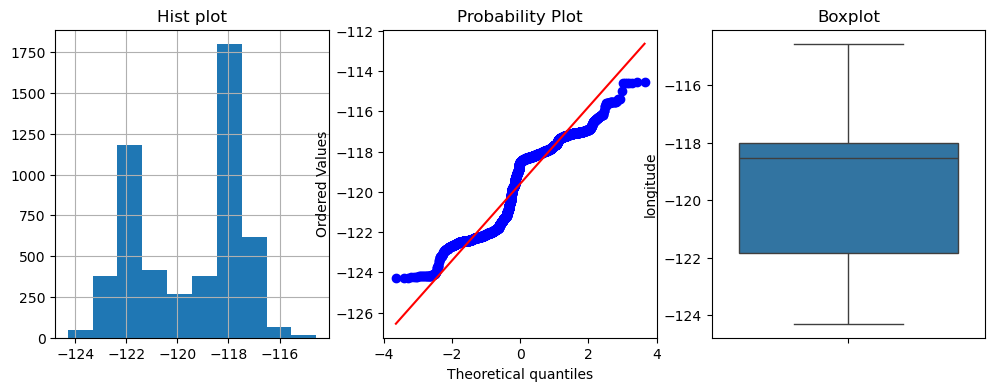

column : latitude


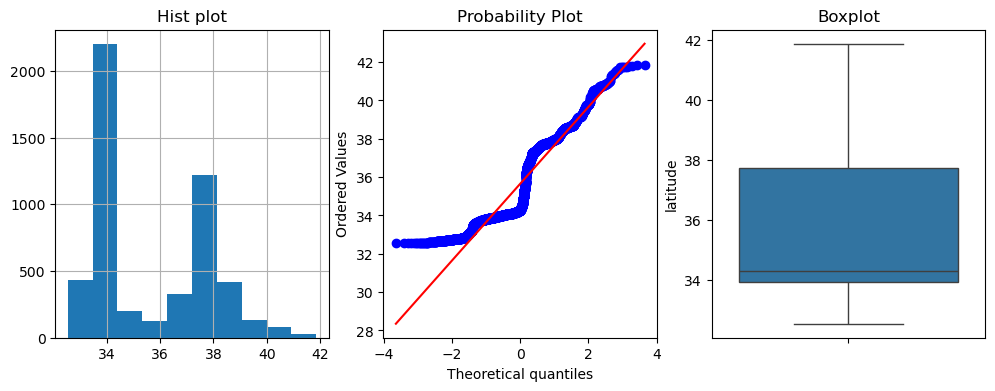

column : housing_median_age


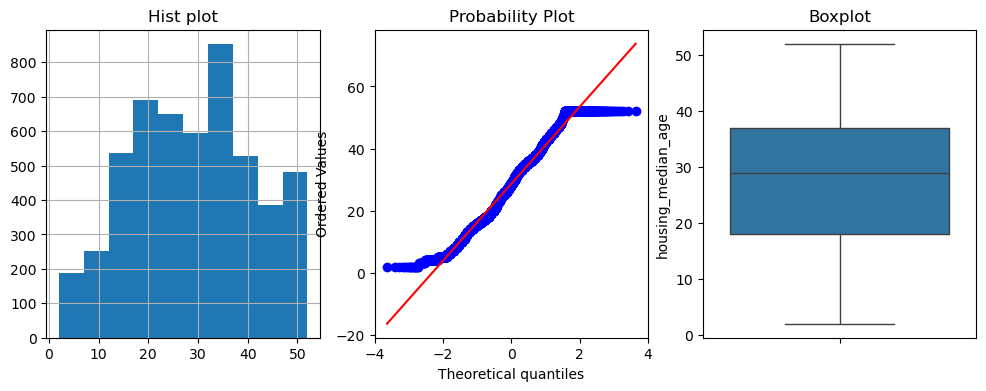

column : total_rooms


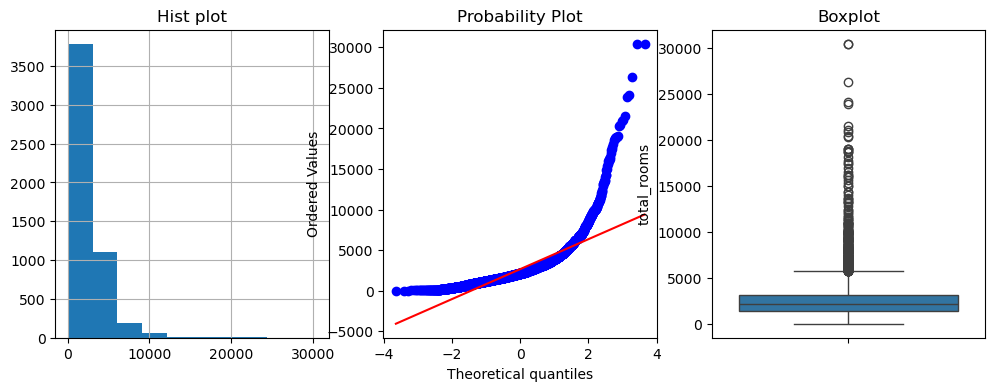

column : total_bedrooms


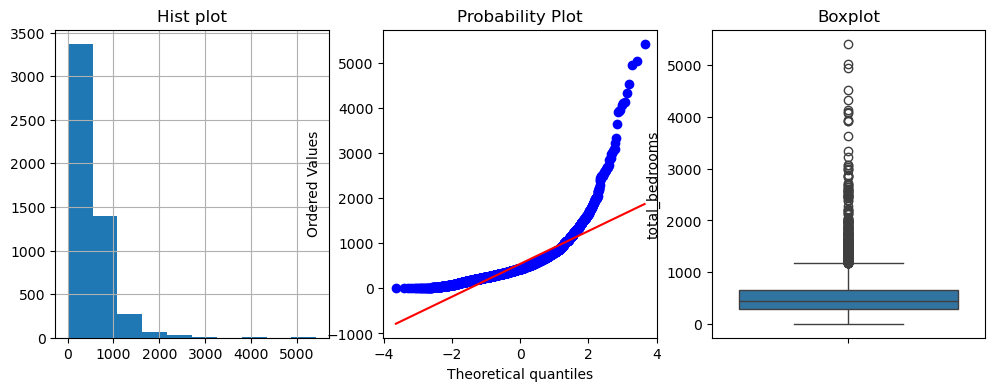

column : population


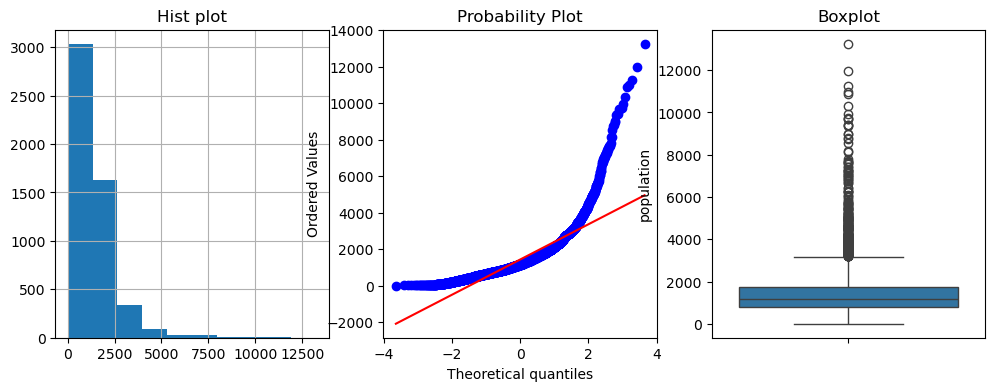

column : households


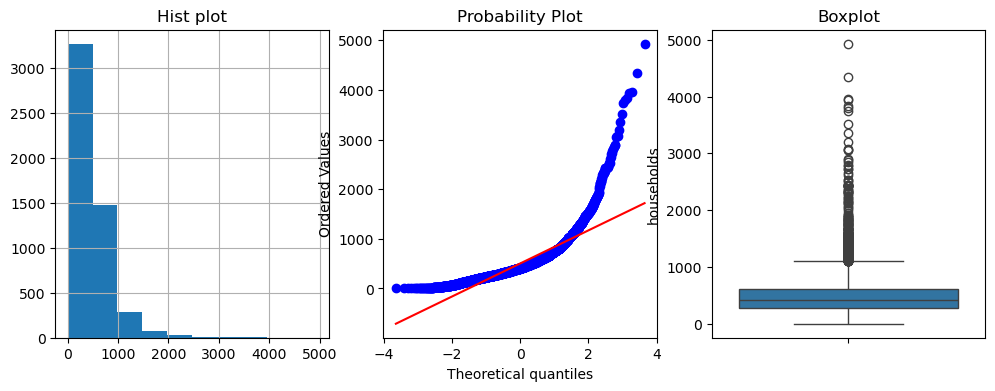

column : median_income


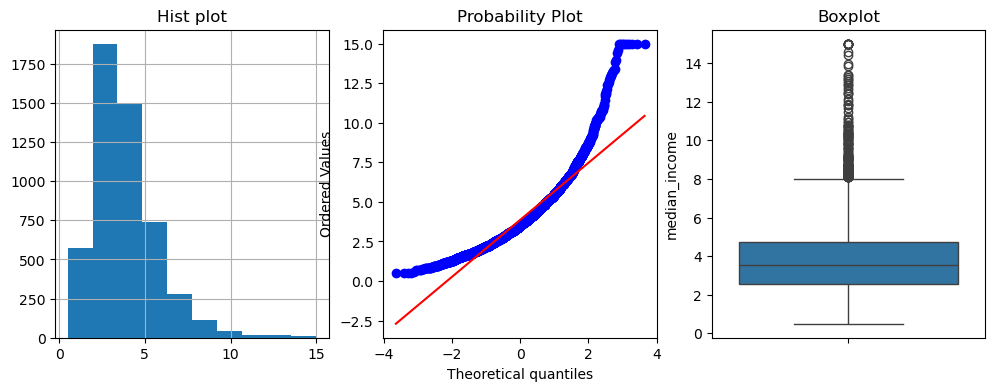

In [24]:
plot_graphs(df_valid)

### Tree based models

In [46]:
### train test splititng the data
y_tree = df_train['median_house_value']
X_tree = df_train.drop('median_house_value', axis = 1)
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, random_state = 42, test_size = 0.30)

In [47]:
### veryfying by checking the shape
print(f"{X_train_tree.shape} : {y_train_tree.shape} :: {X_test_tree.shape} : {y_test_tree.shape}")

(10836, 9) : (10836,) :: (4644, 9) : (4644,)


In [49]:
### importing the tree based models
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
### making the objects
rfr = RandomForestRegressor()
abr = AdaBoostRegressor()
gbr = GradientBoostingRegressor()
dtr = DecisionTreeRegressor()

In [51]:
### using the decision tree first
dtr.fit(X_train_tree, y_train_tree)
y_pred_dtr = dtr.predict(X_test_tree)

In [52]:
### metrices and graphs
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error, roc_curve
### function to plot the metrices
def plot_metrices(y_test, y_pred) :

    print(f"r2 score : {r2_score(y_test, y_pred)}")
    print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE : {root_mean_squared_error(y_test, y_pred)}")
    print(f"MSE : {mean_squared_error(y_test, y_pred)}") 


### function to plot the graphs
def plot_graphs(y_test, y_pred) : 

    plt.figure(figsize = (8, 4))

    #----------line plot with respect to the scatter plot (best fit line)
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)

   #------------------- predicted vs true points
    plt.subplot(1, 2, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)
    plt.show()

r2 score : 0.6564765170786137
MAE : 43721.295865633074
RMSE : 67716.50776605788
MSE : 4585525424.030577


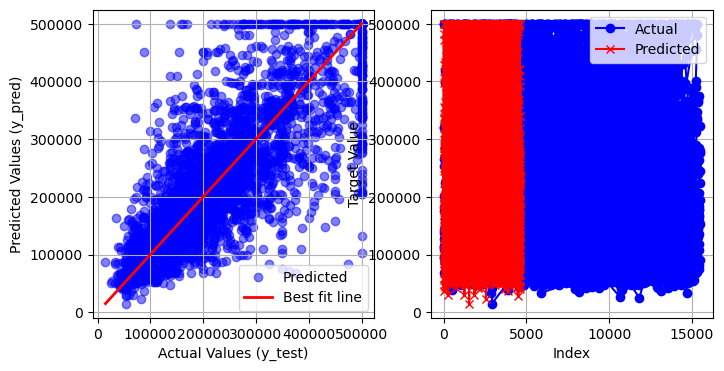

In [53]:
### metrcies and graphs for the 'Decision Tree'
plot_metrices(y_test_tree, y_pred_dtr)
plot_graphs(y_test_tree, y_pred_dtr)

r2 score : 0.33262957324353903
MAE : 82438.57054683723
RMSE : 94384.31246426875
MSE : 8908398439.352716


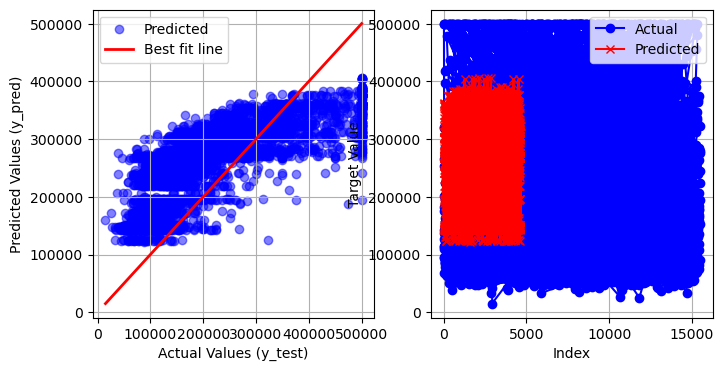

In [ ]:
### Adaboost
abr.fit(X_train_tree, y_train_tree)
y_pred_abr = abr.predict(X_test_tree)
plot_metrices(y_test_tree, y_pred_abr)
plot_graphs(y_test_tree, y_pred_abr)

r2 score : 0.7746552386000372
MAE : 38207.25166209781
RMSE : 54845.38265655132
MSE : 3008015998.743541


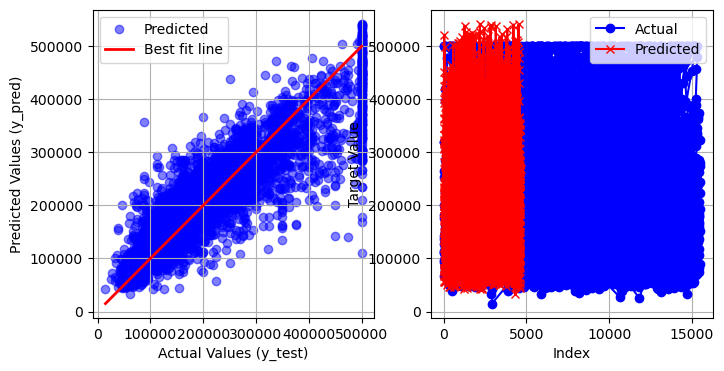

In [55]:
### Graident boost
gbr.fit(X_train_tree, y_train_tree)
y_pred_gbr = gbr.predict(X_test_tree)
plot_metrices(y_test_tree, y_pred_gbr)
plot_graphs(y_test_tree, y_pred_gbr)

r2 score : 0.821687802550649
MAE : 32330.08606373816
RMSE : 48787.30896415709
MSE : 2380201515.964123


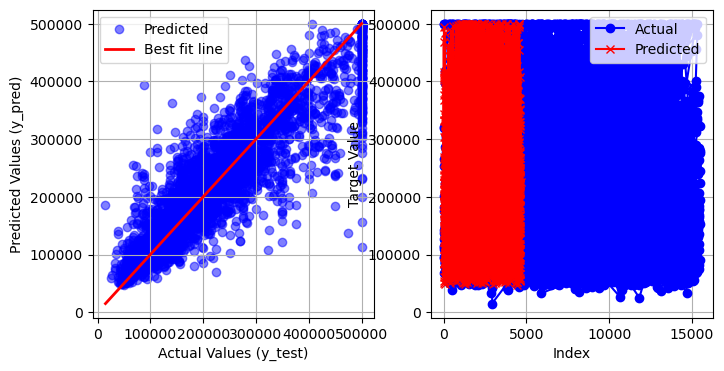

In [56]:
### Random forest
rfr.fit(X_train_tree, y_train_tree)
y_pred_rfr = rfr.predict(X_test_tree)
plot_metrices(y_test_tree, y_pred_rfr)
plot_graphs(y_test_tree, y_pred_rfr)